<a href="https://colab.research.google.com/github/chlaitha/real-world-industry-projects/blob/main/Personal_Financial_Risk_%26_Stress_Prediction_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Personal Financial Risk & Stress Prediction Engine
**Introduction**: This project builds an automated machine learning model to evaluate personal financial vulnerability and stress levels. By analyzing key indicators such as debt-to-income ratios, liquidity metrics, and spending patterns, the predictive engine identifies individuals at elevated risk of financial strain. This allows financial institutions and personal finance platforms to offer proactive support, tailored risk-mitigation strategies, and targeted financial advisory interventions.

In [ ]:
# Import libraries amd suppress warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

# Reproducibility and styling setup
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# Mount Google drive & load data
from google.colab import drive
drive.mount('/content/gdrive')

df = pd.read_csv('/content/gdrive/My Drive/Notebooks/finance.csv')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


#1.Cleaning and Preparing the Data
* **Fixing Dates:** Turns text dates into a standardized calendar format so we can track trends over time.

* **Finding Missing Info:** Scans the dataset to spot and count any blank or missing spots.

* **Filling in Missing Numbers:** Fills in missing numerical values using the middle (median) number of that group. This keeps the data balanced without getting thrown off by unusually high or low numbers.
* **Handling Missing Words:** Fills in missing text categories with the label "Unknown" so we keep all of our records intact without deleting any data points.

In [ ]:
# Coverting the date column to a datetime object
try:
  df['date'] = pd.to_datetime(df['date'])
  print('Converted date column to datetime successfully.')
except Exception as e:
  print('Error converting date column:', e)

# Checking for missing values
  missing_values = df.insull().sum()
  print('Missing values in each column:')
  print(missing_values[missing_values > 0])

# Fills or drops missing values, replacing numeric missingness with the median assuming minimal missing data.
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
  if df[col].isnull().sum() > 0:
    df[col].fillna(df[col].median(), inplace=True)

# For categorical columns, fill missing with the string 'Unknown'
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
  if df[col].isnull().sum() > 0:
    df[col].fillna('Unknown', inplace=True)

print('Data cleaning completed.')

Converted date column to datetime successfully.
Data cleaning completed.


#2.Exploratory Data Analysis (EDA)
* **Checking the Numbers**: Calculates standard statistics—like averages, medians, and ranges—to see the typical values and how widely the data spreads out.

* **Mapping Distributions**: Plots charts for core financial details (such as income, total expenses, savings rates, credit scores, and debt ratios) to see if the data follows a typical pattern or has unusual highs and lows.

* **Spotting Relationships**: Uses a color-coded heatmap to reveal which metrics move together, helping us spot strong connections and overlapping information between variables.

* **Comparing Features Side-by-Side**: Graphs key financial factors directly against each other to visually highlight trends, patterns, and connections across different metrics.

==Descriptive statistics for numeric columns:==
                      date      user_id  monthly_income  \
count                 3000  3000.000000     3000.000000   
mean   2021-06-04 00:00:00  1498.699000     4004.267347   
min    2019-01-01 00:00:00  1000.000000      685.280000   
25%    2020-03-18 12:00:00  1248.750000     3362.250000   
50%    2021-06-04 00:00:00  1496.500000     4008.075000   
75%    2022-08-20 12:00:00  1749.000000     4659.040000   
max    2023-11-06 00:00:00  1999.000000     7407.940000   
std                    NaN   287.352782     1000.107096   

       monthly_expense_total  savings_rate  budget_goal  credit_score  \
count            3000.000000   3000.000000  3000.000000   3000.000000   
mean             3011.682230      0.225897  2811.070463    679.923667   
min               159.210000      0.050000  1175.570000    515.000000   
25%              2473.205000      0.140000  2481.957500    646.000000   
50%              3023.810000      0.230000  2822.285000

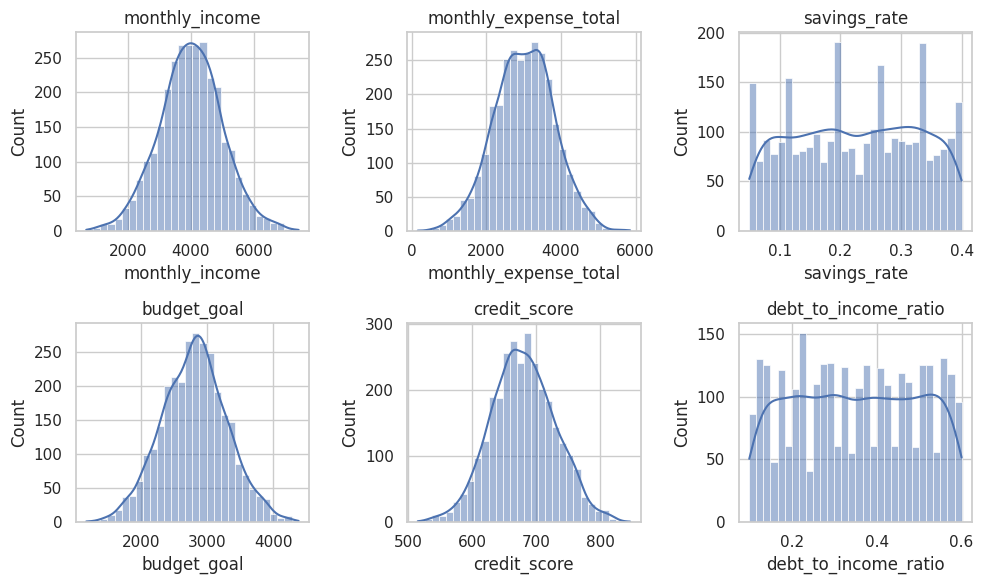

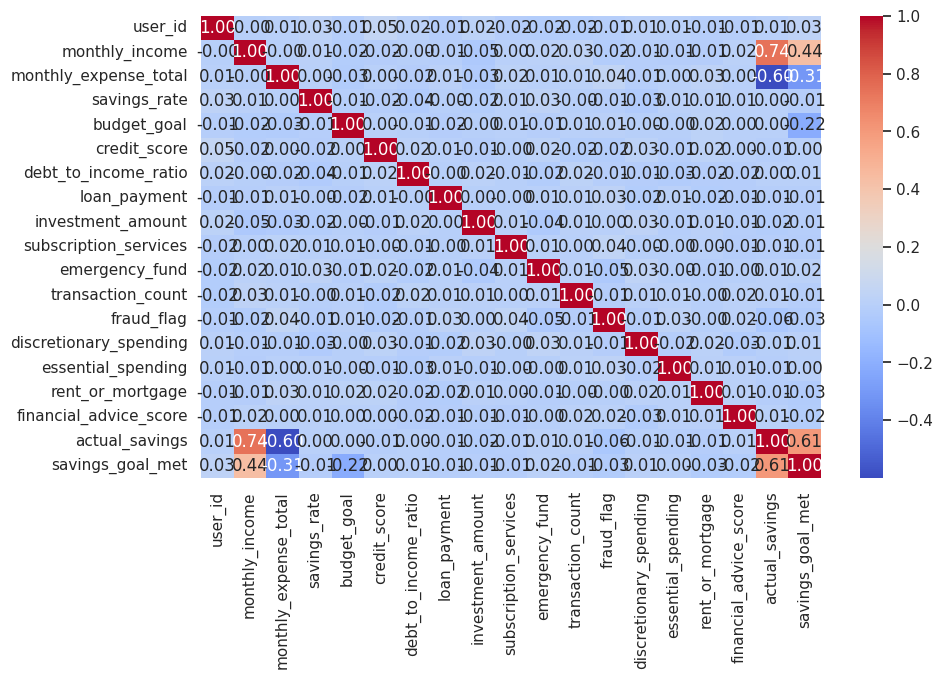

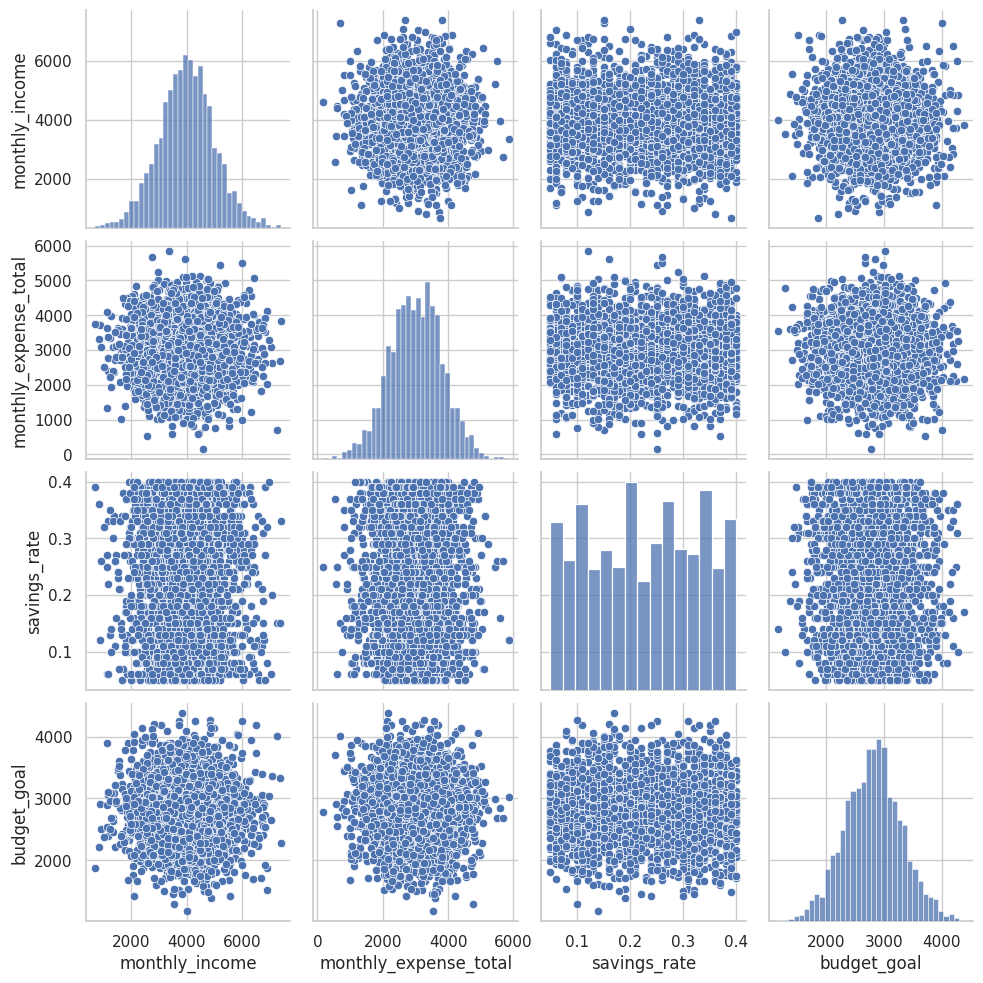

In [ ]:
print('==Descriptive statistics for numeric columns:==')
print(df.describe())

# Plotting histograms for some key numeric features
num_features = ['monthly_income', 'monthly_expense_total', 'savings_rate',
                'budget_goal', 'credit_score', 'debt_to_income_ratio']

fig, axes = plt.subplots(2, 3, figsize=(10, 6)) # Create a 2x3 grid of subplots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(num_features):
  sns.histplot(df[col], kde=True, bins=30, ax=axes[i]) # Plot on the current subplot
  axes[i].set_title(col)

plt.tight_layout()
plt.show()

# If there are four or more numeric columns, create a correlation heatmap
numeric_df = df.select_dtypes(include=[np.number]) # Corrected variable name
if numeric_df.shape[1] >= 4:
  plt.figure(figsize=(10,6)) # Corrected 'plot.figure' to 'plt.figure' and 'figure' to 'figsize'
  corr = numeric_df.corr()
  sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
  plt.show()

# Pair plot of selected numeric features
selected_cols = ['monthly_income', 'monthly_expense_total', 'savings_rate', 'budget_goal']
sns.pairplot(df[selected_cols])
plt.show()

#3.Income Instability & Savings Gaps for Gig Workers

* **Business Problem**: Freelancers and gig-economy workers have unpredictable income, which makes it tough to stick to monthly savings plans or maintain steady cash flow. Banks and fintech platforms need a reliable way to identify high-risk non-salaried users so they can offer flexible credit limits and automated, income-adjusted savings tools.

* **Analysis Summary**: We compared spending habits and savings outcomes between salaried employees and freelancers. By calculating how much of their income goes toward essential bills versus extra spending, we measured how income swings widen the gap between savings goals and actual savings—ultimately reducing how often users meet their targets.

=== Summary by Income Type ===
             avg_monthly_income  avg_essential_ratio  avg_discretionary_ratio  \
income_type                                                                     
Freelance              3968.911                0.615                    0.140   
Mixed                  4064.622                0.587                    0.133   
Salary                 4004.068                0.596                    0.135   

             avg_savings_gap  goal_met_rate  
income_type                                  
Freelance           1630.493          0.112  
Mixed               1591.462          0.098  
Salary              1669.885          0.087  


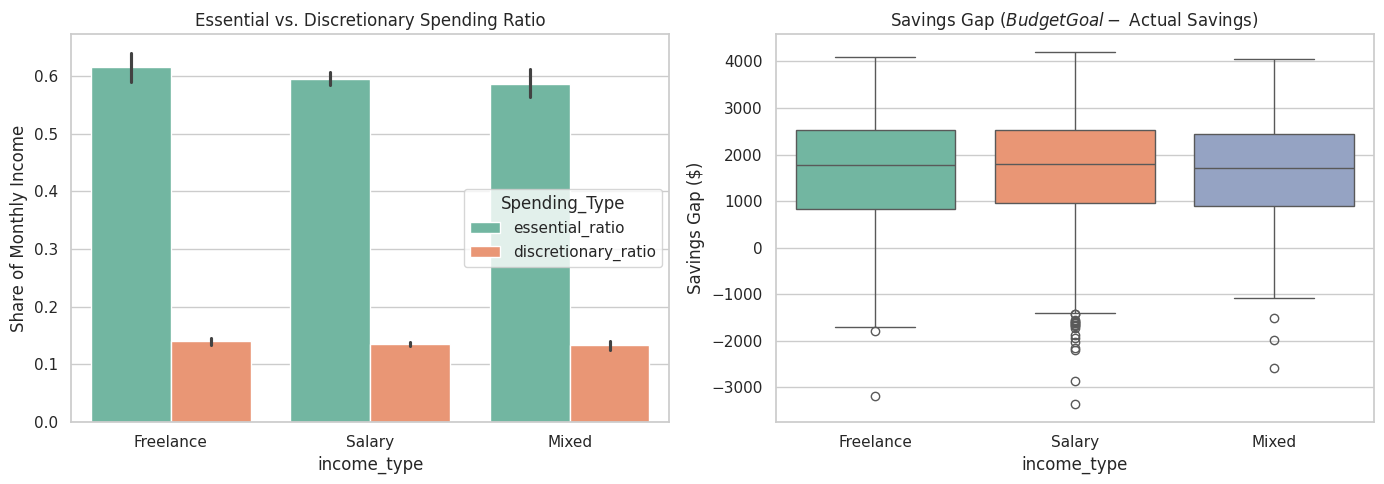

In [ ]:
# Feature engineering
df["essential_ratio"]=df["essential_spending"] / df["monthly_income"]
df["discretionary_ratio"]=df["discretionary_spending"] / df["monthly_income"]
df["savings_gap"]=df["budget_goal"] - df["actual_savings"]

# --- NUMERICAL RESULTS ---
income_group_summary = df.groupby("income_type").agg(
    avg_monthly_income=("monthly_income", "mean"),
    avg_essential_ratio=("essential_ratio", "mean"),
    avg_discretionary_ratio=("discretionary_ratio", "mean"),
    avg_savings_gap=("savings_gap", "mean"),
    goal_met_rate=("savings_goal_met", "mean")
)
print("=== Summary by Income Type ===")
print(income_group_summary.round(3))

# --- PLOTS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Spending Ratios by Employment Type
df_melted = df.melt(
    id_vars=["income_type"],
    value_vars=["essential_ratio", "discretionary_ratio"],
    var_name="Spending_Type",
    value_name="Ratio"
)
sns.barplot(data=df_melted, x="income_type", y="Ratio", hue="Spending_Type", ax=axes[0], palette="Set2")
axes[0].set_title("Essential vs. Discretionary Spending Ratio")
axes[0].set_ylabel("Share of Monthly Income")

# Plot 2: Savings Gap Distribution
sns.boxplot(data=df, x="income_type", y="savings_gap", ax=axes[1], palette="Set2")
axes[1].set_title("Savings Gap ($ Budget Goal - $ Actual Savings)")
axes[1].set_ylabel("Savings Gap ($)")

plt.tight_layout()
plt.show()

#4.Macroeconomic Stress Testing & Vulnerability Mapping

* **Business Problem**: Inflation and economic downturns increase the risk that customers will struggle financially or default on loans. Financial providers need to know exactly which everyday expense categories push households into negative cash flow during tough economic times so they can adjust their lending and risk models accordingly.

* **Analysis Summary**: We evaluated cash flow stability, financial health scores, and stress levels across different economic conditions—normal, inflation, and recession. By tracking spending shifts across essential categories like groceries, utilities, and healthcare, we pinpointed where households feel the heaviest financial strain when prices rise.

=== Financial Health by Macroeconomic Scenario ===
                    avg_actual_savings  avg_advice_score  \
financial_scenario                                         
inflation                      1140.06             50.46   
normal                         1176.39             50.33   
recession                      1117.07             48.93   

                    pct_negative_cash_flow  
financial_scenario                          
inflation                            20.22  
normal                               19.67  
recession                            20.07  

=== Financial Stress Level Distribution (%) ===
financial_stress_level  High   Low  Medium
financial_scenario                        
inflation               19.6  52.8    27.6
normal                  19.5  49.9    30.6
recession               20.7  50.9    28.4


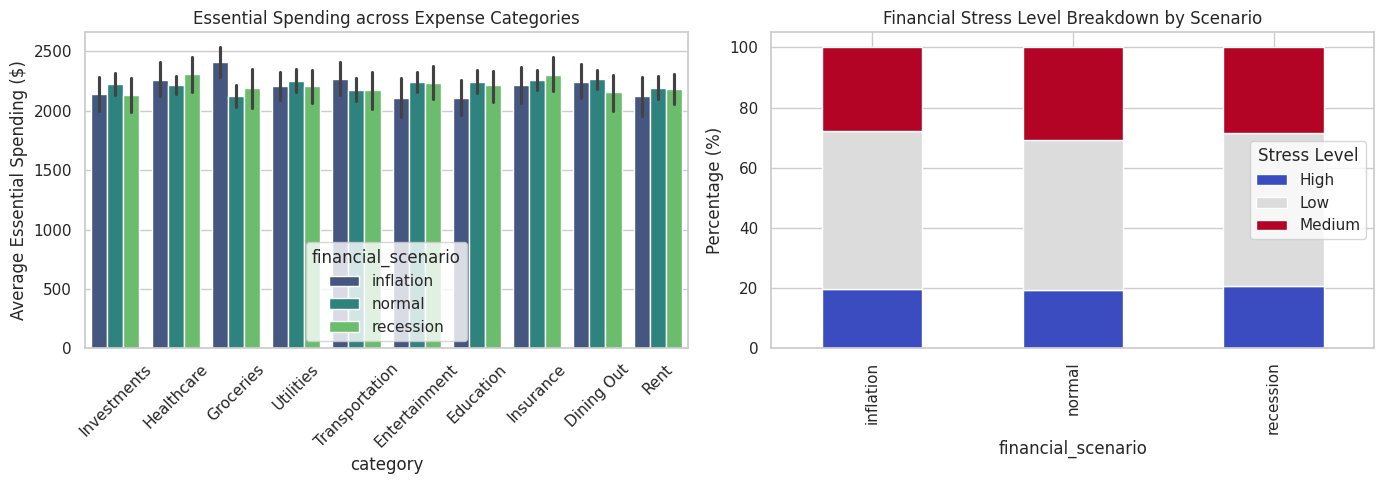

In [ ]:
# --- NUMERICAL RESULTS ---
# Scenario Health Aggregation
scenario_summary = df.groupby("financial_scenario").agg(
    avg_actual_savings=("actual_savings", "mean"),
    avg_advice_score=("financial_advice_score", "mean"),
    pct_negative_cash_flow=("cash_flow_status", lambda x: (x == "Negative").mean() * 100)
)
print("=== Financial Health by Macroeconomic Scenario ===")
print(scenario_summary.round(2))

# Stress Level Crosstab
stress_dist = pd.crosstab(df["financial_scenario"], df["financial_stress_level"], normalize="index") * 100
print("\n=== Financial Stress Level Distribution (%) ===")
print(stress_dist.round(1))

# --- PLOTS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Category Spending Across Scenarios
sns.barplot(
    data=df,
    x="category",
    y="essential_spending",
    hue="financial_scenario",
    ax=axes[0],
    palette="viridis"
)
axes[0].set_title("Essential Spending across Expense Categories")
axes[0].set_ylabel("Average Essential Spending ($)")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Financial Stress Distribution by Scenario
stress_dist.plot(kind="bar", stacked=True, ax=axes[1], colormap="coolwarm")
axes[1].set_title("Financial Stress Level Breakdown by Scenario")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend(title="Stress Level")

plt.tight_layout()
plt.show()

#5.Automated Customer Risk Segmentation & Goal Prediction

* **Business Problem**: Traditional credit scores only show part of the picture and miss real-time financial strain. Fintech apps need dynamic machine learning models to group users by their actual spending habits and predict who is at risk of missing savings goals or running out of cash.

* **Analysis Summary**: We built a Random Forest machine learning model using key factors—like debt ratios, total expenses, and extra spending—to predict whether a user will meet their savings targets. We also used K-Means clustering to automatically group users into clear behavioral profiles (such as High-Income/High-Debt, Frugal Savers, and At-Risk Spenders) to help platforms tailor their support.

=== Feature Importances for Savings Goal Prediction ===
               Feature  Importance
        monthly_income    0.484389
 monthly_expense_total    0.294628
discretionary_spending    0.088280
  debt_to_income_ratio    0.066609
          savings_rate    0.066095

=== Behavioral Cluster Centroids ===
         monthly_income  monthly_expense_total  debt_to_income_ratio  \
cluster                                                                
0.0             3955.92                2291.40                  0.43   
1.0             3986.19                3154.39                  0.21   
2.0             4077.59                3561.76                  0.46   

         discretionary_spending  savings_rate  credit_score  
cluster                                                      
0.0                      499.71          0.26        681.22  
1.0                      516.66          0.23        678.86  
2.0                      481.08          0.18        680.00  


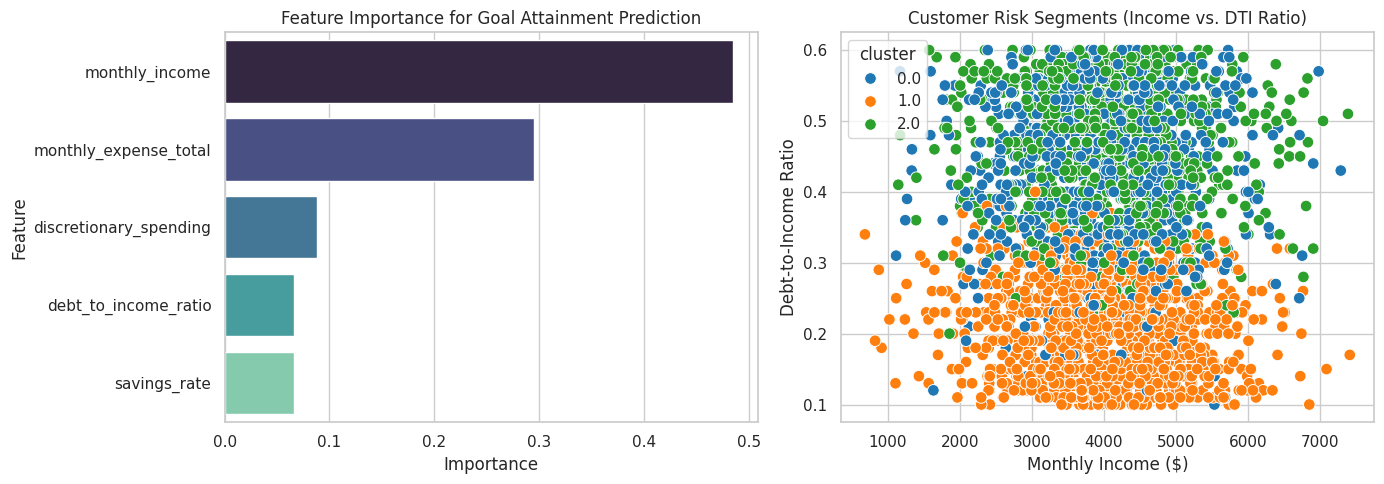

In [ ]:
# 1. Classification (Random Forest)
features = ["monthly_income", "monthly_expense_total", "debt_to_income_ratio", "discretionary_spending", "savings_rate"]
X = df[features].dropna()
y = df.loc[X.index, "savings_goal_met"]

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X, y)

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

# 2. Clustering (K-Means)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df.loc[X.index, "cluster"] = kmeans.fit_predict(X_scaled)

# --- NUMERICAL RESULTS ---
print("=== Feature Importances for Savings Goal Prediction ===")
print(feature_importance.to_string(index=False))

cluster_centers = df.groupby("cluster")[features + ["credit_score"]].mean()
print("\n=== Behavioral Cluster Centroids ===")
print(cluster_centers.round(2))

# --- PLOTS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Feature Importance
sns.barplot(data=feature_importance, x="Importance", y="Feature", ax=axes[0], palette="mako")
axes[0].set_title("Feature Importance for Goal Attainment Prediction")

# Plot 2: Cluster Segmentation Scatter Plot
sns.scatterplot(
    data=df,
    x="monthly_income",
    y="debt_to_income_ratio",
    hue="cluster",
    palette="tab10",
    ax=axes[1],
    s=70
)
axes[1].set_title("Customer Risk Segments (Income vs. DTI Ratio)")
axes[1].set_xlabel("Monthly Income ($)")
axes[1].set_ylabel("Debt-to-Income Ratio")

plt.tight_layout()
plt.show()

#6.Longitudinal Financial Trajectory & Churn Tracking

* **Business Problem**: Banks and budgeting apps lose users when people feel stuck or make slow progress on paying off debt and building savings. Tracking a customer's financial journey over time allows platforms to step in with timely advice, encouragement, and personalized tools before the user gives up or stops using the app.

* **Analysis Summary**: We tracked individual user progress over time to see how their financial habits evolved. By mapping accounts chronologically, we measured key trends like monthly savings growth, changes in debt levels, credit score improvements, and shifts in overall financial health scores to spot when users were gaining momentum or hitting a wall.

=== Longitudinal Trajectory for User ID: 1584 ===
           date  monthly_income  monthly_expense_total  debt_to_income_ratio  \
0    2019-01-01         3119.58                3212.07                  0.56   
2952 2019-12-27         4819.38                2130.07                  0.45   
568  2021-04-20         2028.96                2455.96                  0.37   
1172 2021-08-18         4445.12                2184.64                  0.56   
2792 2021-08-18         4519.37                3956.70                  0.29   
1735 2023-07-09         3614.02                4034.21                  0.13   

      cumulative_savings  credit_score  
0                   0.00         721.0  
2952             2689.31         604.0  
568              2689.31         760.0  
1172             4949.79         710.0  
2792             5512.46         630.0  
1735             5512.46         766.0  


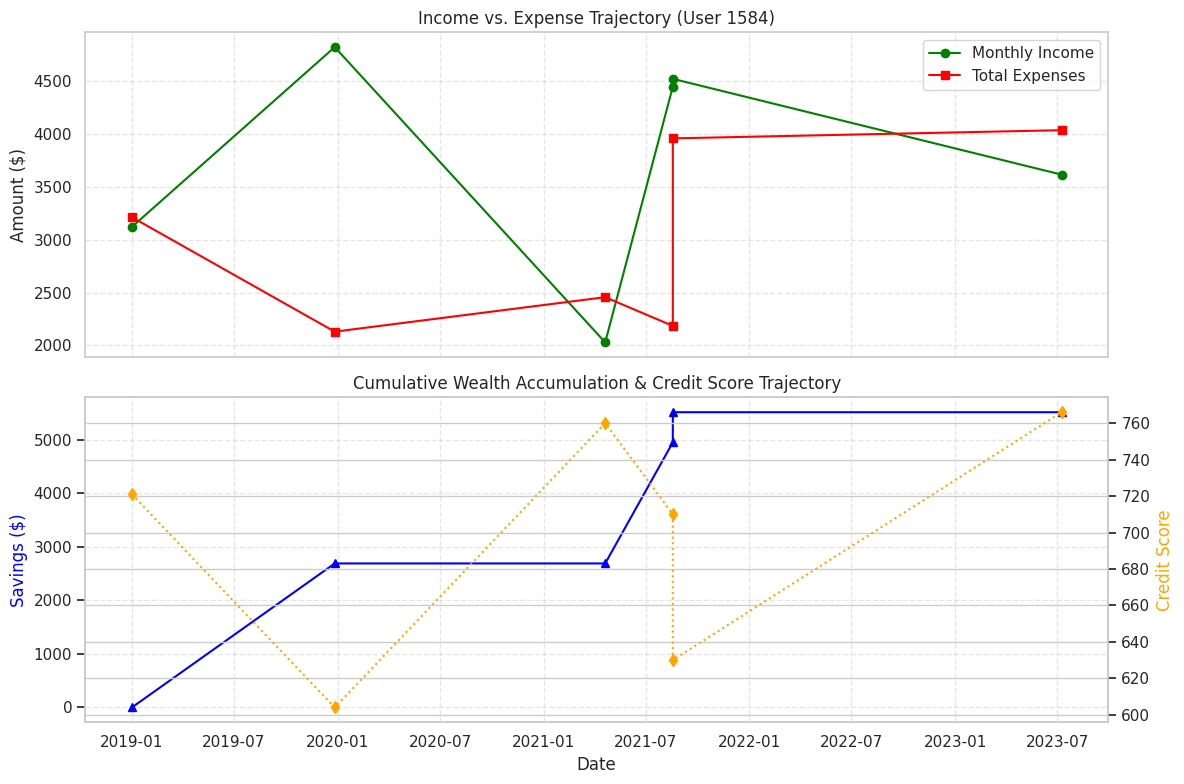

In [ ]:
# Select single user for trajectory analysis
target_user = df["user_id"].iloc[0]
user_df = df[df["user_id"] == target_user].sort_values("date").copy()

user_df["cumulative_savings"] = user_df["actual_savings"].cumsum()
user_df["dti_change_pct"] = user_df["debt_to_income_ratio"].pct_change() * 100

# --- NUMERICAL RESULTS ---
print(f"=== Longitudinal Trajectory for User ID: {target_user} ===")
print(user_df[["date", "monthly_income", "monthly_expense_total", "debt_to_income_ratio", "cumulative_savings", "credit_score"]])

# --- PLOTS ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Monthly Income vs Expenses
axes[0].plot(user_df["date"], user_df["monthly_income"], marker="o", label="Monthly Income", color="green")
axes[0].plot(user_df["date"], user_df["monthly_expense_total"], marker="s", label="Total Expenses", color="red")
axes[0].set_title(f"Income vs. Expense Trajectory (User {target_user})")
axes[0].set_ylabel("Amount ($)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# Plot 2: Cumulative Savings Growth & Credit Score
ax2 = axes[1].twinx()
axes[1].plot(user_df["date"], user_df["cumulative_savings"], marker="^", label="Cumulative Savings", color="blue")
ax2.plot(user_df["date"], user_df["credit_score"], marker="d", label="Credit Score", color="orange", linestyle=":")

axes[1].set_title("Cumulative Wealth Accumulation & Credit Score Trajectory")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Savings ($)", color="blue")
ax2.set_ylabel("Credit Score", color="orange")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#7.Key Findings & Executive Summary
**Widespread Savings Challenges**: Average earnings hold steady around $4,000 per month across all employment types, yet fewer than 11% of users actually meet their savings goals. Freelancers carry the heaviest load, with essential bills eating up over 61% of their earnings..

**Persistent Cash Flow Strain**: One in five households runs a negative cash flow and experiences high financial stress, regardless of whether the broader economy is in a normal period, inflation, or recession.

**What Truly Drives Savings Success**: Total income (48.4%) and monthly fixed expenses (29.5%) are the biggest predictors of hitting savings targets—matters of discretionary spending (8.8%) play a much smaller role than commonly assumed.

**Three Clear User Spending Tiers**:

  * **High Savers (Cluster 0)**: Keep expenses low ($2,291/month) to save 26% of their income, even while carrying moderate debt.

  * **Balanced Spenders (Cluster 1)**: Maintain manageable expenses ($3,154/month) and low debt ratios to consistently save 23%.

  * **At-Risk Spenders (Cluster 2)**: High total expenses ($3,562/month) and heavy debt drag their savings rate down to 18%.

* **Unpredictable Financial Journeys**: Tracking individual users over time highlights sharp ups and downs in income and expenses—often causing spending to outweigh earnings for months at a time and stalling long-term wealth growth.

#8.Actionable Strategies & Implementation Plan
**1. Fixed-Cost Reduction & Smart Budgeting (For High-Expense Users)**
  * **The Challenge**: High fixed bills—rather than extra spending on non-essentials—are the main reason people miss their savings targets.

  * **The Solution**: Launch automated tools that flag recurring subscription costs, help negotiate lower service bills, and send instant budget alerts whenever essential monthly spending tops 75% of take-home pay.

**2. Flexible Savings for Variable-Income Workers (For Freelancers & Gig Workers)**
  * **The Challenge**: Irregular monthly pay causes frequent cash shortages and makes fixed monthly savings goals unrealistic.

  * **The Solution**: Replace rigid dollar targets with flexible savings percentages calculated from a rolling 3-month average. During high-earning months, automatically route extra cash into liquid emergency reserves to cushion future low-earning periods.

**3. Early Warning Alerts for Cash Flow Deficits**
  * **The Challenge**: One in five households regularly spends more than they earn, regardless of broader economic conditions.

  * **The Solution**: Build real-time predictive alerts that trigger supportive options—like temporary spending pauses, flexible credit extensions, or low-interest refinancing—the moment projected monthly expenses are set to exceed earnings.